# 0 Dependencies

In [3]:
%matplotlib widget
import numpy as np
from matplotlib import pyplot as plt
from qutip import QobjEvo, SESolver, expect, MESolver
from qutip.core import destroy, identity, tensor, Qobj, ket, qeye, fidelity, ket2dm
from tqdm.notebook import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import defaultdict

from rlquantopt.rl_envs.zcqubits import ZCQubits, setup_ZCQubits4MKrauss_params
from rlquantopt.utils.rl_utils import get_pulse_data
from weylchamber import c1c2c3, concurrence, WeylChamber

In [3]:
T = 50  # ns
pulse_length = 1000
n_levels = 3
model_params = dict()
model_params["omega_s"] = model_params.get("omega_s", [5.0311, 5.8899])
model_params["alpha_s"] = model_params.get("alpha_s", [-324e-3, -235e-3])
model_params["g"] = model_params.get("g", [100e-3, 71.4e-3])
model_params["alpha_c"] = model_params.get("alpha_c", -230e-3)
model_params["omega_r"] = model_params.get("omega_r", 6.0)
model_params["omega_c_0"] = model_params.get("omega_c_0", 7.445)
model_params["n_levels"] = n_levels = model_params.get("n_levels", n_levels)
model_params["num_qubits"] = num_qubits = model_params.get("num_qubits", 2)
model_params["coupler_dims"] = model_params.get("coupler_dims", n_levels)
model_params["qubit_dims"] = [n_levels] * num_qubits

# 1 Load pulse from CSV file

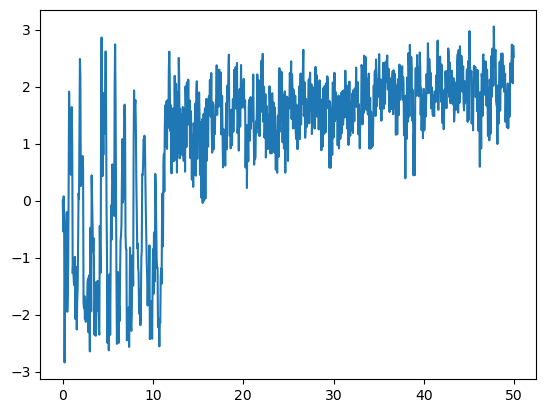

In [3]:
# pulse_path = r'C:\Users\mirko\Desktop\rlquantopt-main\rl_model_12566528_steps_ZCQPEE_pl-1000_T-50ns_delta_mode_ep0_no_term.csv'
pulse_path = '/home/leander/code/rlquantopt/rlquantopt/rl_agents/ZCQPEE_pl-1000_T-50ns_delta_mode-TRPO/05-12-24_201634/results/no_term/rl_model_12566528_steps_ZCQPEE_pl-1000_T-50ns_delta_mode_ep0_no_term.csv'
tlist, pulse = get_pulse_data(pulse_path)
plt.plot(tlist, np.divide(pulse, 2*np.pi))
plt.show()

In [12]:
dt=tlist[1]

0.05

# 2 SESolver

In [11]:
# Set up initial states
full_dims = model_params.get("qubit_dims").copy()
full_dims.append(model_params.get("coupler_dims"))
psi00 = ket((0, 0, 0), dim=full_dims)
psi01 = ket((0, 1, 0), dim=full_dims)
psi10 = ket((1, 0, 0), dim=full_dims)
psi11 = ket((1, 1, 0), dim=full_dims)
basis_states_ket = [psi00, psi01, psi10, psi11]
basis_states = basis_states_ket.copy()
initial_states = basis_states.copy()

# Set up SE solvers
# options = dict(method='adams')#, atol=1e-10, rtol=1e-8, order=5)
options = dict(method='adams', atol=1e-10, rtol=1e-8)

simulator = ZCQubits(**model_params)

solvers = [SESolver(simulator.H, options=options) for _ in range(len(basis_states))]
# solvers = [MESolver(simulator.H, options=options) for _ in range(len(basis_states))]

basis_states_str = ('$|000\\rangle$', '$|010\\rangle$', '$|100\\rangle$', '$|110\\rangle$',)
tlist = np.linspace(T/pulse_length, T, pulse_length)

for k, initial_state in enumerate(basis_states):
    solvers[k].start(initial_state, 0.)

all_states = []
for i, (t, amp) in enumerate(zip(tlist, pulse)):
    final_states = []
    for k, _ in enumerate(basis_states):
        final_state = solvers[k].step(t, args=dict(A=amp))
        final_states.append(final_state)
    all_states.append(final_states.copy())
all_states = np.array(all_states)
all_states.shape

(1000, 4)

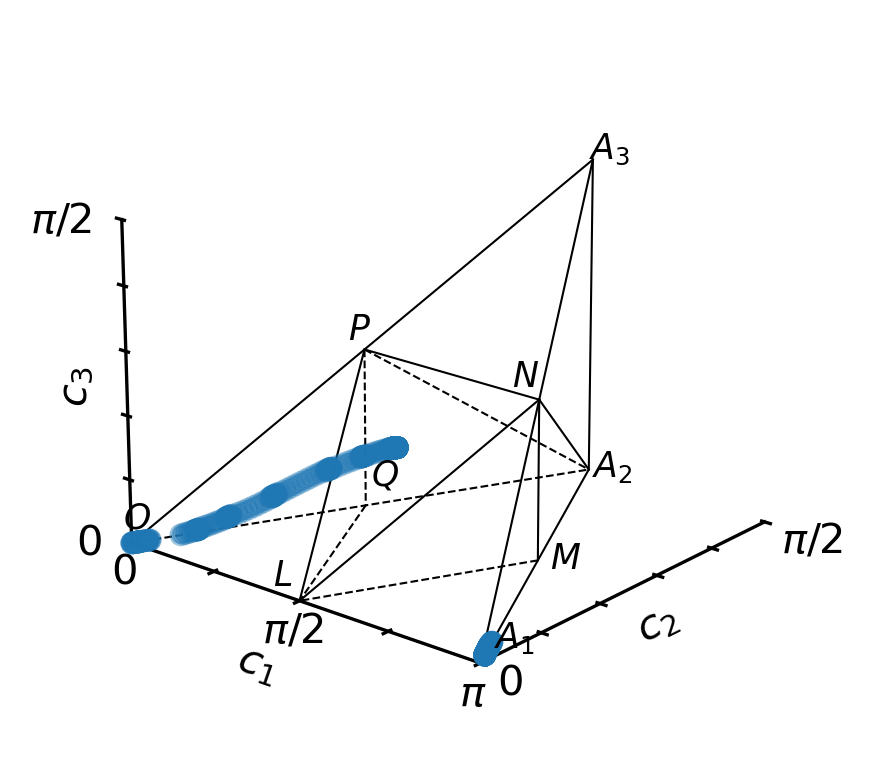

In [13]:
n_states = len(basis_states)

cs = []
us = []
wc = WeylChamber()
for h, step_states in enumerate(all_states):
    realised_gate = np.zeros(shape=(n_states, n_states), dtype=np.complex128)
    for i, s in enumerate(step_states):
        for j, b in enumerate(basis_states):
            realised_gate[i, j] = s.overlap(b)
    realised_gate = Qobj(realised_gate, dims=([[2, 2], [2, 2]]))
    # print(np.matrix.round(realised_gate.full(), 3))
    # print(realised_gate.norm())

    c1, c2, c3 = c1c2c3(realised_gate)
    wc.add_point(c1, c2, c3)
    c = concurrence(c1, c2, c3)
    u = (realised_gate.dag() * realised_gate).tr() / 4

    cs.append(c)
    us.append(u)
    # print(f'{h}: C={c:.4f}, U={u:.4f}')
wc.plot()
cs = np.array(cs)
us = np.array(us)
plt.show()

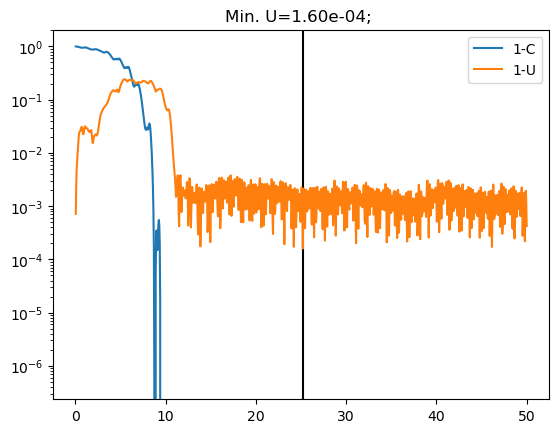

In [14]:
uerr = 1 - us
argmin = np.argmin(uerr)
t_min = tlist[argmin]
u_min = uerr[argmin]
plt.title(f"Min. U={u_min:.2e}; ")
plt.axvline(t_min, c='k')
plt.plot(tlist, 1 - cs, label='1-C')
plt.plot(tlist, uerr, label='1-U')
plt.yscale('log')
plt.legend(loc='best')
plt.show()

## Testing diff. number of levels

/tmp/ipykernel_12464/255676363.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  col = mpl.cm.get_cmap('tab10')(_i, len(N_LEVELS))


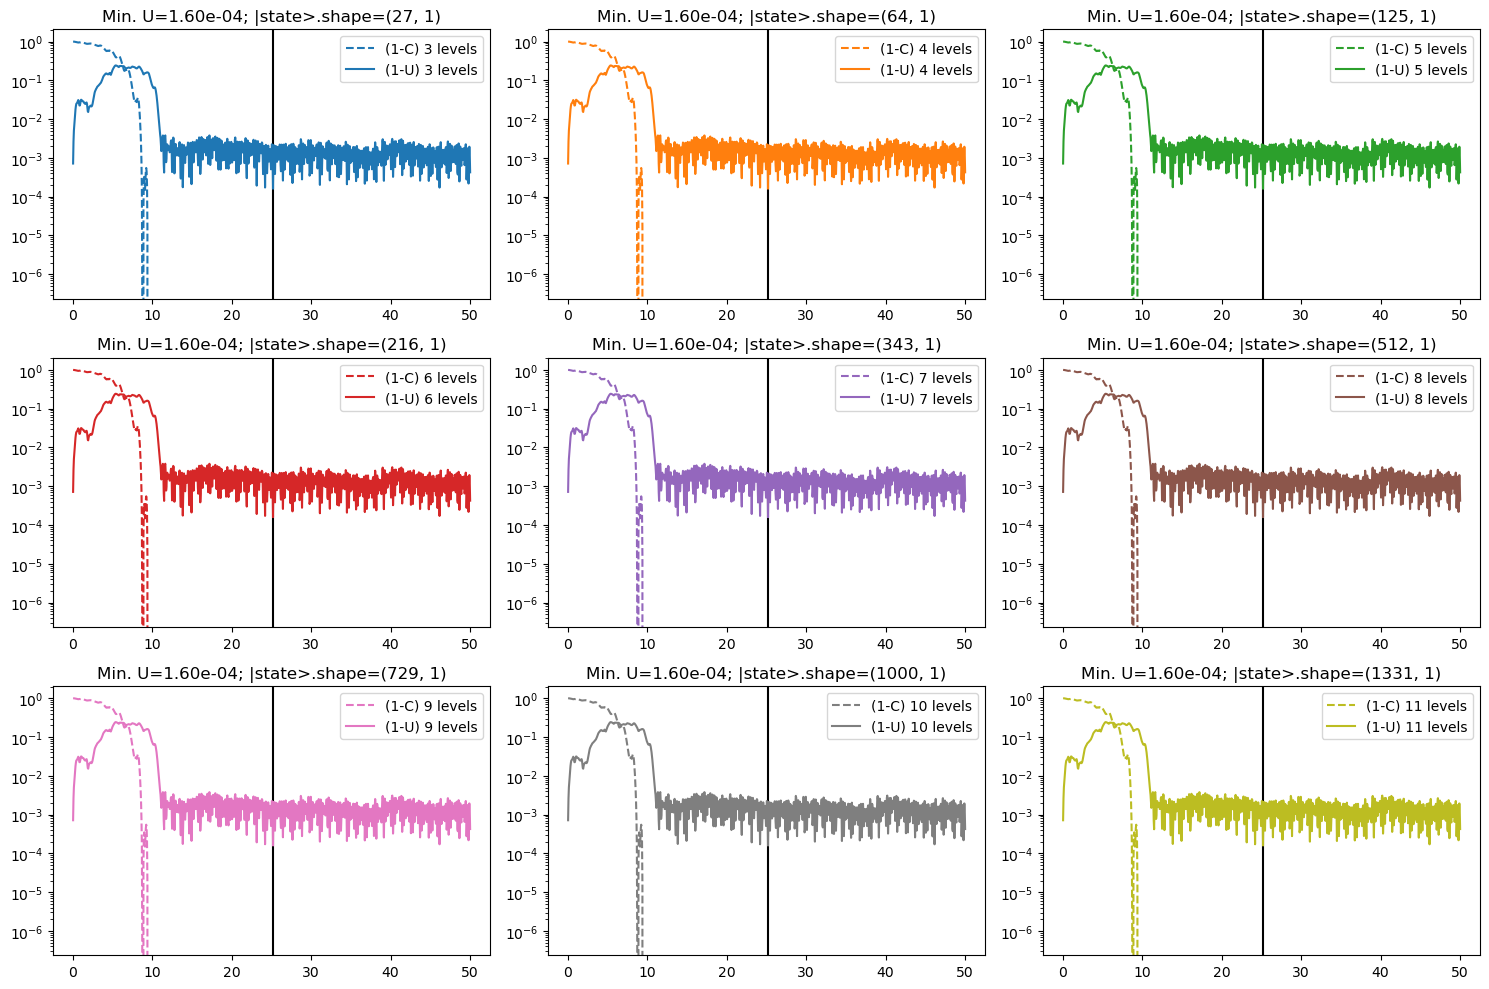

In [18]:
from collections import defaultdict
import matplotlib as mpl

cs = defaultdict(list)
us = defaultdict(list)

fig, axs = plt.subplots(3, 3, figsize=(15, 10))
axs = np.array(axs).flatten()

N_LEVELS = (3, 4, 5, 6, 7, 8, 9, 10, 11)

for _i, n_levels in enumerate(N_LEVELS):
    # if _i > 3:
    #     break
    col = mpl.cm.get_cmap('tab10')(_i, len(N_LEVELS))
    # Set up initial states
    model_params["coupler_dims"] = n_levels
    model_params["n_levels"] = n_levels
    model_params["qubit_dims"] = [n_levels] * model_params["num_qubits"]
    
    full_dims = model_params.get("qubit_dims").copy()
    full_dims.append(model_params.get("coupler_dims"))
    psi00 = ket((0, 0, 0), dim=full_dims)
    psi01 = ket((0, 1, 0), dim=full_dims)
    psi10 = ket((1, 0, 0), dim=full_dims)
    psi11 = ket((1, 1, 0), dim=full_dims)
    basis_states_ket = [psi00, psi01, psi10, psi11]
    basis_states = basis_states_ket.copy()
    initial_states = basis_states.copy()
    
    # Set up SE solvers
    # options = dict(method='adams')#, atol=1e-10, rtol=1e-8, order=5)
    options = dict(method='adams', atol=1e-10, rtol=1e-8)
    
    simulator = ZCQubits(**model_params)
    
    solvers = [SESolver(simulator.H, options=options) for _ in range(len(basis_states))]
    # solvers = [MESolver(simulator.H, options=options) for _ in range(len(basis_states))]
    
    basis_states_str = ('$|000\\rangle$', '$|010\\rangle$', '$|100\\rangle$', '$|110\\rangle$',)
    tlist = np.linspace(T/pulse_length, T, pulse_length)
    
    for k, initial_state in enumerate(basis_states):
        solvers[k].start(initial_state, 0.)
    
    all_states = []
    for _, (t, amp) in enumerate(zip(tlist, pulse)):
        final_states = []
        for k, _ in enumerate(basis_states):
            final_state = solvers[k].step(t, args=dict(A=amp))
            final_states.append(final_state)
        all_states.append(final_states.copy())
    all_states = np.array(all_states)

    n_states = len(basis_states)

    # cs = []
    # us = []
    for h, step_states in enumerate(all_states):
        realised_gate = np.zeros(shape=(n_states, n_states), dtype=np.complex128)
        for i, s in enumerate(step_states):
            for j, b in enumerate(basis_states):
                realised_gate[i, j] = s.overlap(b)
        realised_gate = Qobj(realised_gate, dims=([[2, 2], [2, 2]]))
    
        c1, c2, c3 = c1c2c3(realised_gate)
        c = concurrence(c1, c2, c3)
        u = (realised_gate.dag() * realised_gate).tr() / 4
    
        cs[n_levels].append(c)
        us[n_levels].append(u)

    cerr = np.subtract(1, cs[n_levels])
    uerr = np.subtract(1, us[n_levels])
    
    argmin = np.argmin(uerr)
    t_min = tlist[argmin]
    u_min = uerr[argmin]

    ax = axs[_i]
    ax.set_title(f"Min. U={u_min:.2e}; |state>.shape={basis_states[0].shape}")
    ax.axvline(t_min, color='k')
    ax.plot(tlist, cerr, label=f'(1-C) {n_levels} levels', c=col, ls='dashed')
    ax.plot(tlist, uerr, label=f'(1-U) {n_levels} levels', c=col)
    
    ax.set_yscale('log')
    ax.legend(loc='best')
    
fig.tight_layout()
plt.show()

Nb. levels=3: Averge J_T error in SESolver = 1.21e-08
Nb. levels=4: Averge J_T error in SESolver = 2.96e-08
Nb. levels=5: Averge J_T error in SESolver = 4.59e-08
Nb. levels=6: Averge J_T error in SESolver = 6.93e-08
Nb. levels=7: Averge J_T error in SESolver = 8.72e-08
Nb. levels=8: Averge J_T error in SESolver = 1.10e-07
Nb. levels=9: Averge J_T error in SESolver = 1.42e-07
Nb. levels=10: Averge J_T error in SESolver = 1.61e-07


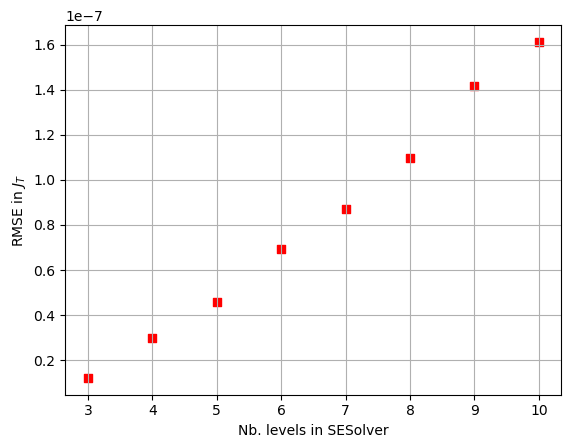

In [29]:
udiffs = {}
errs = []
jt3 = 0.25 * np.array(cs[3]) + 0.75 * np.array(us[3])
for n_levels in N_LEVELS[:-1]:
    udiffs[n_levels] = np.sqrt(np.mean(np.square(np.subtract(jt3, 0.25 * np.array(cs[n_levels + 1]) + 0.75 * np.array(us[n_levels + 1])))))
    errs.append(udiffs[n_levels])
    print(f"Nb. levels={n_levels}: Averge J_T error in SESolver = {errs[-1]:.2e}")
fig, ax = plt.subplots()
ax.grid()
ax.scatter(N_LEVELS[:-1], errs, marker='s', c='r')
# ax.set_yscale('log')

ax.set_xlabel("Nb. levels in SESolver")
ax.set_ylabel("RMSE in $J_T$")
fig.savefig('J_T_error_vs_energy_levels.pdf')
plt.show()

# 3 MESolver

## 3.1 Set up c_ops

In [4]:
def get_c_ops(n_levels, qubit_indices, num_qubits=3, T1=100e3):
    gamma = 1.0 / T1
    c_ops = []

    for q in qubit_indices:
        op_list = []
        for i in range(num_qubits):  # 3 qutrits
            if i == q:
                op_list.append(destroy(n_levels))
            else:
                op_list.append(qeye(n_levels))
        c_op = np.sqrt(gamma) * tensor(op_list)
        c_ops.append(c_op)

    return c_ops

## 3.2 Get DMs without c_ops

In [28]:
N_LEVELS = (6,)#(3, 4, 5)#, 6, 7, 8, 9, 10, 11)
# step_states_no_noise = {}
dt = tlist[1]
mesolver_options = dict(method='adams', 
                        max_step=dt/2)
for _i, n_levels in enumerate(N_LEVELS):
    col = mpl.cm.get_cmap('tab10')(_i, len(N_LEVELS))
    
    # Set up initial states
    model_params["coupler_dims"] = n_levels
    model_params["n_levels"] = n_levels
    model_params["qubit_dims"] = [n_levels] * model_params["num_qubits"]
    
    # Set up initial states
    full_dims = model_params.get("qubit_dims").copy()
    full_dims.append(model_params.get("coupler_dims"))
    psi00 = ket((0, 0, 0), dim=full_dims)
    psi01 = ket((0, 1, 0), dim=full_dims)
    psi10 = ket((1, 0, 0), dim=full_dims)
    psi11 = ket((1, 1, 0), dim=full_dims)
    basis_states_ket = [psi00, psi01, psi10, psi11]
    basis_states = basis_states_ket.copy()
    initial_states = basis_states.copy()
    
    # Set up ME solvers    
    simulator = ZCQubits(**model_params)

    solvers = [MESolver(simulator.H, options=mesolver_options) for _ in range(len(basis_states))]
    # solvers = [MESolver(simulator.H, options=options) for _ in range(len(basis_states))]
    
    basis_states_str = ('$|000\\rangle$', '$|010\\rangle$', '$|100\\rangle$', '$|110\\rangle$',)
    tlist = np.linspace(T/pulse_length, T, pulse_length)
    
    for k, initial_state in enumerate(basis_states):
        solvers[k].start(initial_state, 0.)
    
    all_states = []
    for i, (t, amp) in tqdm(enumerate(zip(tlist, pulse))):
        final_states = []
        # print(t, amp)
        for k, _ in enumerate(basis_states):
            final_state = solvers[k].step(t, args=dict(A=amp))
            final_states.append(final_state)
        all_states.append(final_states.copy())
    step_states_no_noise[n_levels] = np.array(all_states)

/tmp/ipykernel_8953/2792876800.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  col = mpl.cm.get_cmap('tab10')(_i, len(N_LEVELS))


0it [00:00, ?it/s]

## 3.3 Get DMs with $T_1=100\mu s$

In [41]:
N_LEVELS = (6,)#(3, 4, 5)#, 6, 7, 8, 9, 10, 11)
T1 = 100e3 #units ns
# step_states_t1 = {}
dt = tlist[1]
mesolver_options = dict(method='lsoda', 
                        # nsteps=5000)
                        max_step=dt/2)
for _i, n_levels in enumerate(N_LEVELS):
    col = mpl.cm.get_cmap('tab10')(_i, len(N_LEVELS))
    
    # Set up initial states
    model_params["coupler_dims"] = n_levels
    model_params["n_levels"] = n_levels
    model_params["qubit_dims"] = [n_levels] * model_params["num_qubits"]
    
    # Set up initial states
    full_dims = model_params.get("qubit_dims").copy()
    full_dims.append(model_params.get("coupler_dims"))
    psi00 = ket((0, 0, 0), dim=full_dims)
    psi01 = ket((0, 1, 0), dim=full_dims)
    psi10 = ket((1, 0, 0), dim=full_dims)
    psi11 = ket((1, 1, 0), dim=full_dims)
    basis_states_ket = [psi00, psi01, psi10, psi11]
    basis_states = basis_states_ket.copy()
    initial_states = basis_states.copy()
    
    options = dict(progress_bar='tqdm')
    
    simulator = ZCQubits(**model_params)
    c_ops = get_c_ops(n_levels=n_levels, qubit_indices=[0,1, 2], T1=T1)

    print("H.dims:", simulator.H.dims)
    for i, c in enumerate(c_ops):
        print(f"c_ops[{i}].dims:", c.dims)

    solvers = [MESolver(simulator.H, c_ops=c_ops, options=mesolver_options) for _ in range(len(basis_states))]
    # solvers = [MESolver(simulator.H, options=options) for _ in range(len(basis_states))]
        
    tlist = np.linspace(T/pulse_length, T, pulse_length)
    
    for k, initial_state in enumerate(basis_states):
        solvers[k].start(initial_state, 0.)
    
    all_states = []
    for i, (t, amp) in tqdm(enumerate(zip(tlist, pulse))):
        final_states = []
        # print(t, amp)
        for k, _ in enumerate(basis_states):
            final_state = solvers[k].step(t, args=dict(A=amp))
            final_states.append(final_state)
        all_states.append(final_states.copy())
    step_states_t1[n_levels] = np.array(all_states)

/tmp/ipykernel_8953/2815471286.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  col = mpl.cm.get_cmap('tab10')(_i, len(N_LEVELS))


H.dims: [[6, 6, 6], [6, 6, 6]]
c_ops[0].dims: [[6, 6, 6], [6, 6, 6]]
c_ops[1].dims: [[6, 6, 6], [6, 6, 6]]
c_ops[2].dims: [[6, 6, 6], [6, 6, 6]]


MemoryError: Unable to allocate 64.9 GiB for an array with shape (8707969174,) and data type float64

## 3.4 Save DM evolutions

In [29]:
import pickle as pkl
with open('step_states_no_noise.pkl', 'wb') as f:
    pkl.dump(step_states_no_noise, f)
with open('step_states_t1.pkl', 'wb') as f:
    pkl.dump(step_states_t1, f)

In [30]:
print(list(step_states_t1), list(step_states_no_noise))

[3, 4, 5, 6] [3, 4, 5, 6]


# 4 MESolver Results - DMs fidelity evolution

In [7]:
import pickle as pkl
T = 50
pulse_length = 1000
with open('step_states_no_noise.pkl', 'rb') as f:
    step_states_no_noise = pkl.load(f)
with open('step_states_t1.pkl', 'rb') as f:
    step_states_t1 = pkl.load(f)
with open('step_states_diff_evo_fidelities.pkl', 'rb') as f:
    fidelities = pkl.load(f)
tlist = np.linspace(T/pulse_length, T, pulse_length)

## 4.1 Calculate fidelity evolution

In [31]:
N_LEVELS = (6,)#(3,4,5)#,6)
# fidelities = defaultdict(lambda: defaultdict(list))
for n_levels in N_LEVELS:
    for i, (rho_s_no_noise, rho_s_t1) in enumerate(zip(tqdm(step_states_no_noise[n_levels]), step_states_t1[n_levels])):
        # for j, rho_b in enumerate(basis_states_dm):
        for j, (a, b) in enumerate(zip(rho_s_no_noise, rho_s_t1)):
            A = Qobj(a)
            B = Qobj(b)
            f = fidelity(A, B)
            fidelities[n_levels][j].append(f)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [33]:
with open('step_states_diff_evo_fidelities.pkl', 'wb') as f:
    pkl.dump(dict(fidelities), f)

In [17]:
print(list(fidelities.keys()))
print(list(step_states_no_noise.keys()))#
print(list(step_states_t1.keys()))

[3, 4, 5, 6]
[3, 4, 5, 6]
[3, 4, 5, 6]


## 4.2 Plotting

In [5]:
N_LEVELS = (3,4,5)
basis_states_str = ('$|000\\rangle$', '$|010\\rangle$', '$|100\\rangle$', '$|110\\rangle$',)


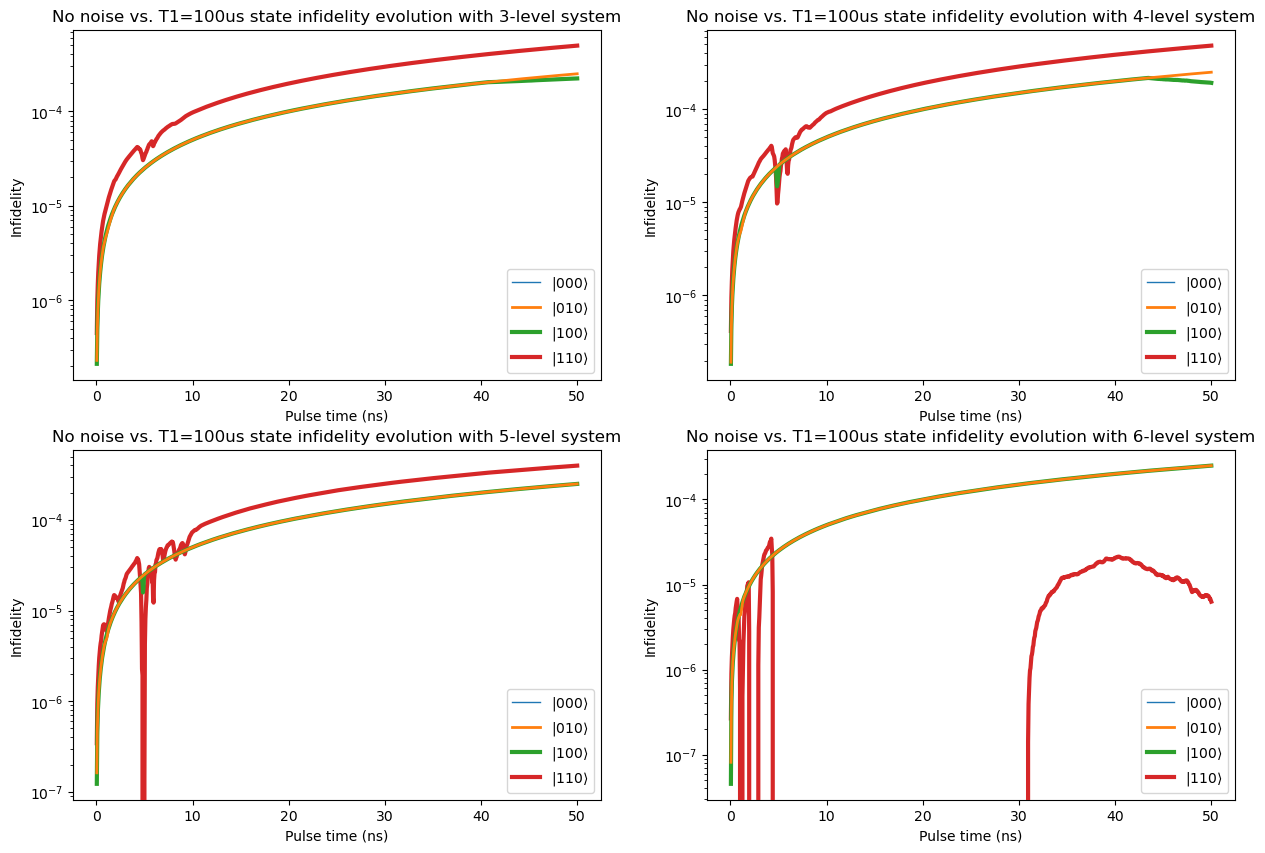

In [39]:
fig, axs = plt.subplots(2, 2, figsize=(15,10)) 
axs = np.array(axs).flat
for i, n_levels in enumerate(N_LEVELS): 
    ax = axs[i]
    fids_ = fidelities[n_levels]
    for k, f in fids_.items():
        f_inv = np.subtract(1, f)
        ax.plot(tlist, f_inv, label=basis_states_str[int(k)], lw=np.clip(a_min=0,a_max=3., a=(k+1) * 1), zorder=15 - k)
    ax.set_title(f'No noise vs. T1=100us state infidelity evolution with {n_levels}-level system')
    ax.set_ylabel(f'Infidelity')
    ax.set_xlabel(f'Pulse time (ns)')
    ax.set_yscale('log')
    ax.legend(loc='best')
fig.savefig(f'fidelity_evolution_{N_LEVELS}-levels_level-comparison.pdf')
plt.show()

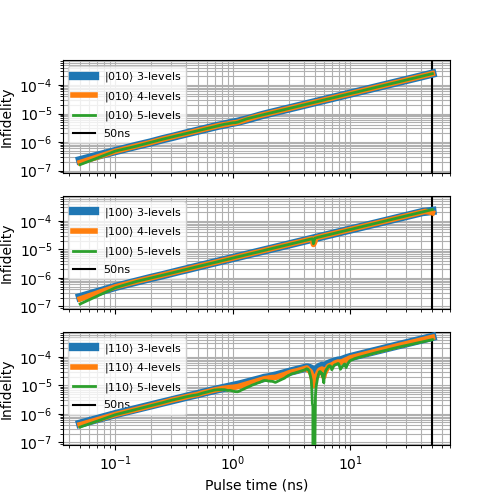

In [24]:
fig, axs = plt.subplots(3, figsize=(5,5), sharey=True, sharex=True)
axs = np.array(axs).flat
# axs[0].set_title(f'No noise vs. T1=100us state infidelity evolution')
for b_ in range(3):
    ax = axs[b_]
    ax.grid(which='both')
    for n_levels in N_LEVELS:
        fids_ = fidelities[n_levels]
        # for k, f in fids_.items():
        f_inv = np.subtract(1, fids_[b_ + 1]) # |110> basis state evolution is most interesting
        ax.plot(tlist, f_inv, label=f"{basis_states_str[int(b_ + 1)]} {n_levels}-levels", lw=(6 - n_levels)*2, zorder=15)

    xticks = ax.get_xticks()
    xticks = np.append(xticks, 50)
    ax.set_xticks(xticks)
    ax.set_ylabel(f'Infidelity')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.axvline(tlist[-1], c='k', label='50ns')
    ax.legend(loc='best', fontsize=8)
ax.set_xlabel(f'Pulse time (ns)')
# axs[-1].remove()
fig.savefig(f'fidelity_evolution_{N_LEVELS}-levels_basis-state-comparison.pdf', bbox_inches='tight')

plt.show()

In [23]:
ax.get_xticklabels()

[Text(0.001, 0, '$\\mathdefault{10^{-3}}$'),
 Text(0.01, 0, '$\\mathdefault{10^{-2}}$'),
 Text(0.1, 0, '$\\mathdefault{10^{-1}}$'),
 Text(1.0, 0, '$\\mathdefault{10^{0}}$'),
 Text(10.0, 0, '$\\mathdefault{10^{1}}$'),
 Text(100.0, 0, '$\\mathdefault{10^{2}}$'),
 Text(1000.0, 0, '$\\mathdefault{10^{3}}$')]

In [38]:
# Set up initial states
model_params["coupler_dims"] = n_levels
model_params["n_levels"] = n_levels
model_params["qubit_dims"] = [n_levels] * model_params["num_qubits"]

# Set up initial states
full_dims = model_params.get("qubit_dims").copy()
full_dims.append(model_params.get("coupler_dims"))
psi00 = ket((0, 0, 0), dim=full_dims)
psi01 = ket((0, 1, 0), dim=full_dims)
psi10 = ket((1, 0, 0), dim=full_dims)
psi11 = ket((1, 1, 0), dim=full_dims)
basis_states_ket = [psi00, psi01, psi10, psi11]
basis_states = basis_states_ket.copy()

# Old

  0%|          | 0/1000 [00:00<?, ?it/s]

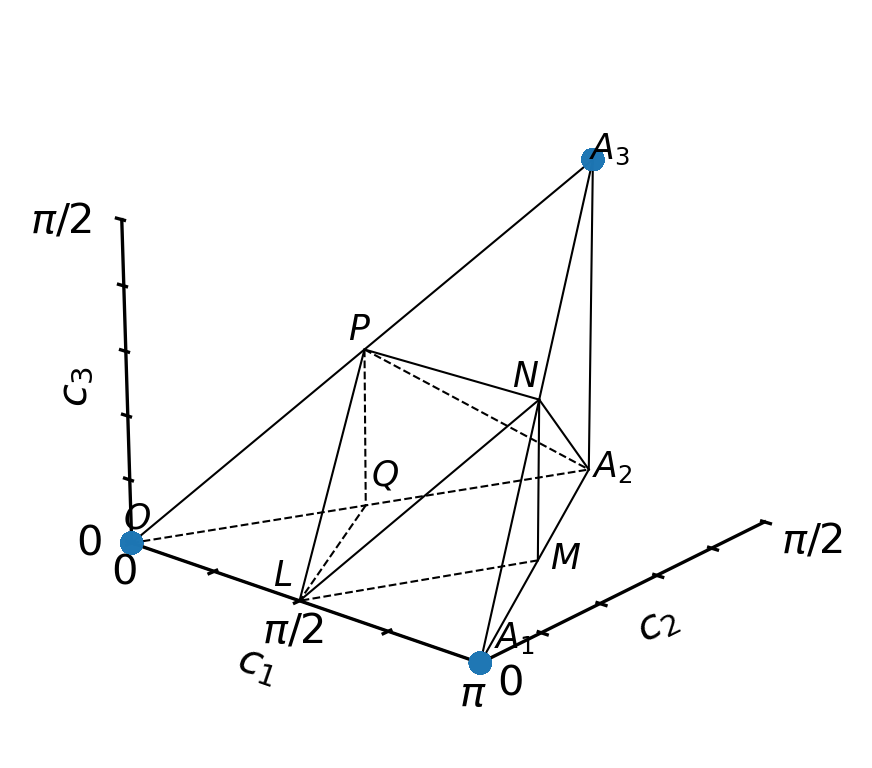

In [14]:
wc = WeylChamber()
cs = []
us = []
for h, step_states in enumerate(tqdm(all_states)):
    realised_gate = np.zeros(shape=(n_states, n_states), dtype=np.complex128)
    
    for i, rho_s in enumerate(step_states):
        for j, rho_b in enumerate(basis_states_dm):
            # rho_b = b * b.dag()
            # Overlap calculation between two density matrices
            overlap = (rho_s @ rho_b).tr()
            realised_gate[i, j] = overlap

    realised_gate = Qobj(realised_gate, dims=([[2, 2], [2, 2]]))
    rgs.append(realised_gate)

    try:
        c1, c2, c3 = c1c2c3(realised_gate)
        wc.add_point(c1, c2, c3)
    
        c = concurrence(c1, c2, c3)
        u = (realised_gate.dag() * realised_gate).tr() / 4
    
        cs.append(c)
        us.append(u)
    except Exception as e:
        print(e)
        print(realised_gate.shape, realised_gate)
        break

wc.plot()
cs = np.array(cs)
us = np.array(us)
plt.show()

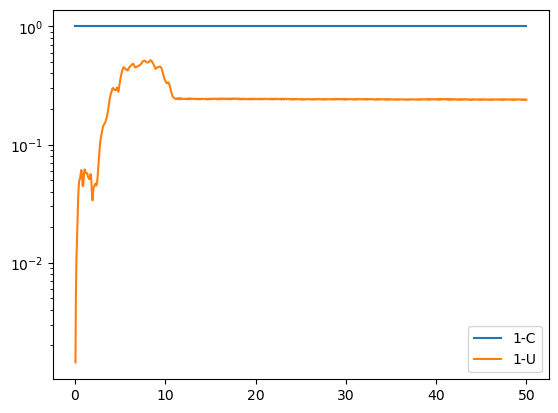

In [13]:
plt.plot(tlist[:len(cs)], 1 - cs, label='1-C')
plt.plot(tlist[:len(cs)], 1 - us, label='1-U')
plt.yscale('log')
plt.legend(loc='best')
plt.show()